# Capstone: ¿Podemos confiar en las calificaciones de cine de Fandango?

## Contexto

Imagina que estás planeando ir al cine. Antes de comprar el boleto, revisas las **estrellas** que muestra el sitio donde vas a comprar. Pero, ¿qué pasaría si esa misma empresa **gana dinero vendiéndote el boleto** y al mismo tiempo es quien decide qué calificación mostrarte? ¿Tendría incentivo a inflar las notas para que las películas se vean más atractivas?

En **2015**, el periodista de datos **Walt Hickey** publicó en *FiveThirtyEight* un artículo que destapó exactamente eso: [*Be Suspicious Of Online Movie Ratings, Especially Fandango's*](https://fivethirtyeight.com/features/fandango-movies-ratings/). Hickey descubrió que las **estrellas mostradas** en Fandango.com no coincidían con las **calificaciones reales** que el propio sistema calculaba: estaban **redondeadas hacia arriba** de manera sistemática.

En este proyecto vas a **reconstruir y extender ese análisis** desde cero usando pandas, matplotlib y seaborn. Tu misión: confirmar (o refutar) las conclusiones de Hickey con tus propios datos.

---

## Los datasets

El equipo de FiveThirtyEight publicó dos archivos abiertos en [su repositorio de GitHub](https://github.com/fivethirtyeight/data):

### `fandango_scrape.csv`
Cada película que Fandango mostraba en su sitio al 24 de agosto de 2015.

| Columna | Definición |
|---|---|
| `FILM`   | Título de la película (incluye año entre paréntesis) |
| `STARS`  | Estrellas **mostradas** públicamente en Fandango.com (visualmente, lo que ve el cliente) |
| `RATING` | Calificación **verdadera** extraída del HTML interno de la página (`ratingValue`). Es el promedio real |
| `VOTES`  | Cantidad de personas que habían reseñado la película al momento del scraping |

> **Clave:** la diferencia entre `STARS` y `RATING` es el corazón del análisis. Si Fandango fuera honesto, `STARS` sería simplemente `RATING` redondeado al medio entero más cercano. Si está inflando, redondeará hacia arriba con más frecuencia que hacia abajo.

### `all_sites_scores.csv`
Para cada película que tenga al menos 30 reseñas en Fandango, las calificaciones agregadas en otros sitios.

| Columna | Definición |
|---|---|
| `FILM` | Título de la película |
| `RottenTomatoes` | Tomatometer (críticos profesionales), escala 0–100 |
| `RottenTomatoes_User` | Calificación de usuarios en RT, escala 0–100 |
| `Metacritic` | Metascore de críticos, escala 0–100 |
| `Metacritic_User` | Calificación de usuarios en Metacritic, escala 0–10 |
| `IMDB` | Calificación de usuarios en IMDb, escala 0–10 |
| `Metacritic_user_vote_count` | Número de votos de usuarios en Metacritic |
| `IMDB_user_vote_count` | Número de votos de usuarios en IMDb |

---

## Plan de trabajo

El proyecto está dividido en **tres partes**:

1. **Fandango por dentro:** ¿coincide la calificación mostrada (`STARS`) con la verdadera (`RATING`)?
2. **Comparación con otros sitios:** ¿qué pasa con Rotten Tomatoes, Metacritic e IMDb? ¿Hay coherencia entre críticos y usuarios?
3. **Fandango vs. el mundo:** una vez normalizadas todas las escalas a 0–5, ¿muestra Fandango calificaciones sistemáticamente más altas?

Al final tendrás suficiente evidencia para responder la pregunta del título con datos en la mano.


---

## Instrucciones

- Cada bloque tiene una pregunta de negocio o analítica que motivar el código.
- Las tareas están marcadas como **TAREA:** seguidas del enunciado.
- Resuelve cada tarea en la celda con `# TU CÓDIGO AQUÍ`.
- Lee siempre el comentario interpretativo después de cada gráfico — ahí es donde está el insight.

> **Tip:** muchas operaciones se resuelven en una o dos líneas. Si te encuentras escribiendo más de 5–6 líneas para una sola tarea, probablemente hay un atajo de pandas o seaborn que no estás usando.


## Parte 1 — Contexto

Antes de tocar una sola línea de código, **lee el artículo original**: [Be Suspicious Of Online Movie Ratings, Especially Fandango's](https://fivethirtyeight.com/features/fandango-movies-ratings/).

Es corto, está en inglés y plantea con claridad la hipótesis que vamos a verificar. Tómate 5 minutos. Una vez termines, regresa aquí.

---

## Configuración inicial

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Silenciar warnings al asignar columnas a slices (común en EDA)
import warnings
warnings.simplefilter('ignore')

---

## Parte 2 — Lo que muestra Fandango vs. lo que realmente calcula

Vamos a empezar por dentro: **dentro del propio Fandango**, ¿coincide la calificación que se le muestra al cliente (`STARS`) con la calificación promedio real (`RATING`)?

### Carga del dataset

In [12]:
fandango = pd.read_csv('fandango_scrape.csv')

**TAREA 1:** Inspecciona el DataFrame con `head()`, `info()` y `describe()`. Familiarízate con su contenido.

In [13]:
# Primeras filas del DataFrame
fandango.head()

,FILM,STARS,RATING,VOTES
0,Fifty Shades of Grey (2015),4.0,3.9,34846
1,Jurassic World (2015),4.5,4.5,34390
2,American Sniper (2015),5.0,4.8,34085
3,Furious 7 (2015),5.0,4.8,33538
4,Inside Out (2015),4.5,4.5,15749


In [14]:
# Resumen de tipos y valores no nulos
fandango.info()

<class 'pandas.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   FILM    504 non-null    str    
 1   STARS   504 non-null    float64
 2   RATING  504 non-null    float64
 3   VOTES   504 non-null    int64  
dtypes: float64(2), int64(1), str(1)
memory usage: 15.9 KB


In [15]:
# Estadísticos descriptivos de las columnas numéricas
fandango.describe()

,STARS,RATING,VOTES
count,504.000000,504.000000,504.000000
mean,3.558532,3.375794,1147.863095
std,1.563133,1.491223,3830.583136
min,0.000000,0.000000,0.000000
25%,3.500000,3.100000,3.000000
50%,4.000000,3.800000,18.500000
75%,4.500000,4.300000,189.750000
max,5.000000,5.000000,34846.000000


### Popularidad vs. calificación

**TAREA 2:** Construye un **scatterplot** que relacione la calificación (`RATING`) con la cantidad de votos (`VOTES`). ¿Existe alguna relación entre lo popular que es una película y lo bien calificada que está?

<Axes: xlabel='RATING', ylabel='VOTES'>

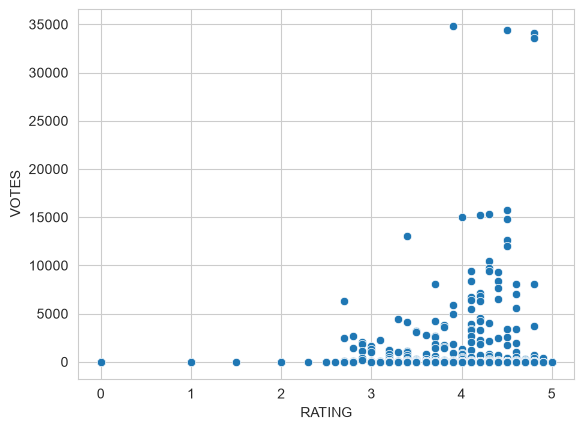

In [16]:
# Relación entre calificación y votos
sns.scatterplot(data=fandango, x='RATING', y='VOTES')

**TAREA 3:** Calcula la **matriz de correlación** entre las columnas numéricas. ¿Hay correlaciones fuertes entre `STARS`, `RATING` y `VOTES`?

In [17]:
# Matriz de correlación de las columnas numéricas
fandango.corr(numeric_only=True)

,STARS,RATING,VOTES
STARS,1.000000,0.994696,0.164218
RATING,0.994696,1.000000,0.163764
VOTES,0.164218,0.163764,1.000000


### Extraer el año del título

**TAREA 4:** Cada título tiene el formato `Nombre de la Película (AÑO)`. Crea una columna `AÑO` que extraiga ese valor del string en `FILM`.

In [18]:
# Extraer el año que está entre paréntesis al final del título
fandango['AÑO'] = fandango['FILM'].str.extract(r'\((\d{4})\)').astype(int)

**TAREA 5:** ¿Cuántas películas hay por año en el dataset?

In [19]:
# Películas estrenadas por año
fandango['AÑO'].value_counts().sort_index()

AÑO
1964      1
2012      1
2014     24
2015    477
2016      1
Name: count, dtype: int64

**TAREA 6:** Visualiza el conteo de películas por año con un `countplot`.

<Axes: xlabel='AÑO', ylabel='count'>

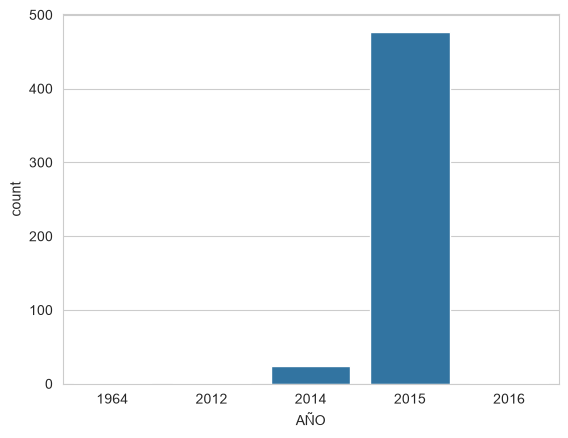

In [20]:
# Conteo de películas por año (gráfico de barras)
sns.countplot(data=fandango, x='AÑO')

### Las 10 películas más votadas

**TAREA 7:** Encuentra las **10 películas con mayor cantidad de votos** en Fandango.

In [21]:
# Las 10 películas con más votos, de mayor a menor
fandango.nlargest(10, 'VOTES')[['FILM', 'VOTES']]

,FILM,VOTES
0,Fifty Shades of Grey (2015),34846
1,Jurassic World (2015),34390
2,American Sniper (2015),34085
3,Furious 7 (2015),33538
4,Inside Out (2015),15749
5,The Hobbit: The Battle of the Five Armies (2014),15337
6,Kingsman: The Secret Service (2015),15205
7,Minions (2015),14998
8,Avengers: Age of Ultron (2015),14846
9,Into the Woods (2014),13055


**TAREA 8:** ¿Cuántas películas tienen **cero votos**?

In [22]:
# Cantidad de películas sin votos (VOTES == 0)
fandango['VOTES'].eq(0).sum()

np.int64(69)

**TAREA 9:** Las películas sin votos no nos sirven para analizar comportamiento de calificaciones (no hay nada que calificar). Crea un nuevo DataFrame `fan_resenadas` que contenga **solo las películas con al menos un voto**.

In [23]:
# Solo películas con al menos un voto
fan_resenadas = fandango[fandango['VOTES'] > 0]

---

### El núcleo del análisis: estrellas mostradas vs. calificación verdadera

Como explica el artículo, debido a cómo se renderizan las estrellas en HTML (medias estrellas), la **calificación mostrada** (`STARS`) puede diferir ligeramente de la **calificación real** (`RATING`). Vamos a visualizar esa diferencia.

**TAREA 10:** Construye un único gráfico con **dos KDE plots** superpuestos: uno para `RATING` (calificación verdadera) y otro para `STARS` (estrellas mostradas). Limita el rango a 0–5.

(0.0, 5.0)

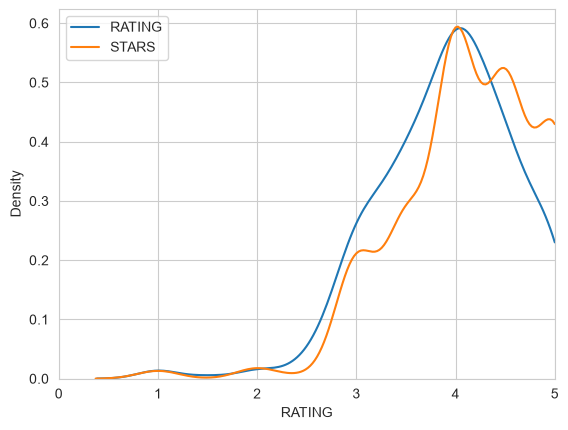

In [24]:
# Densidad de la calificación verdadera vs. las estrellas mostradas
sns.kdeplot(data=fan_resenadas, x='RATING', label='RATING', clip=[0, 5])
sns.kdeplot(data=fan_resenadas, x='STARS', label='STARS', clip=[0, 5])
plt.legend()
plt.xlim(0, 5)

### Cuantificar la diferencia

**TAREA 11:** Crea una columna `STARS_DIFF = STARS - RATING` redondeada a 2 decimales. Esta columna captura, película por película, **cuánto infla Fandango la nota**.

In [25]:
# Cuánto infla Fandango: estrellas mostradas menos calificación real
fan_resenadas['STARS_DIFF'] = (fan_resenadas['STARS'] - fan_resenadas['RATING']).round(2)

**TAREA 12:** Construye un `countplot` que muestre cuántas veces aparece cada valor de `STARS_DIFF`. Usa la paleta `magma`.

<Axes: xlabel='STARS_DIFF', ylabel='count'>

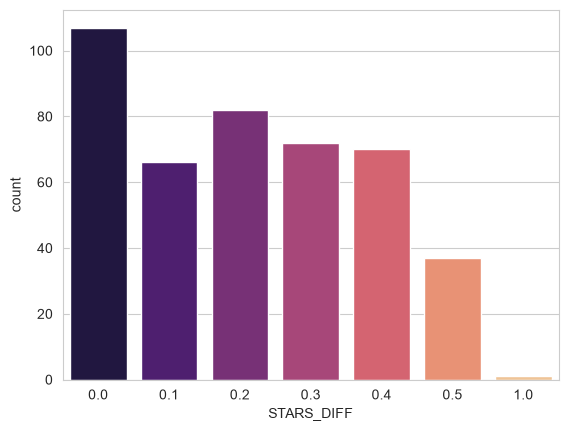

In [26]:
# Frecuencia de cada diferencia entre estrellas y calificación
sns.countplot(data=fan_resenadas, x='STARS_DIFF', palette='magma')

**TAREA 13:** En el countplot anterior se nota un caso extremo con diferencia ≈ 1.0 estrella. ¿Cuál es esa película?

In [27]:
# Película con el caso extremo de ~1 estrella de inflado
fan_resenadas[fan_resenadas['STARS_DIFF'] >= 1.0][['FILM', 'STARS', 'RATING', 'STARS_DIFF']]

,FILM,STARS,RATING,STARS_DIFF
381,Turbo Kid (2015),5.0,4.0,1.0


---

## Parte 3 — Comparación con Rotten Tomatoes, Metacritic e IMDb

Hasta aquí ya sabemos que Fandango infla las estrellas que muestra. Pero falta una pregunta más profunda: **¿qué tan altas son las calificaciones de Fandango comparadas con sitios independientes?** Para esto necesitamos los datos de los demás sitios.

### Carga del segundo dataset

In [28]:
all_sites = pd.read_csv('all_sites_scores.csv')

**TAREA 14:** Inspecciona `all_sites` con `head()`, `info()` y `describe()`.

In [29]:
# Primeras filas del segundo dataset
all_sites.head()

,FILM,RottenTomatoes,RottenTomatoes_User,Metacritic,Metacritic_User,IMDB,Metacritic_user_vote_count,IMDB_user_vote_count
0,Avengers: Age of Ultron (2015),74,86,66,7.1,7.8,1330,271107
1,Cinderella (2015),85,80,67,7.5,7.1,249,65709
2,Ant-Man (2015),80,90,64,8.1,7.8,627,103660
3,Do You Believe? (2015),18,84,22,4.7,5.4,31,3136
4,Hot Tub Time Machine 2 (2015),14,28,29,3.4,5.1,88,19560


In [30]:
# Resumen de tipos y valores no nulos
all_sites.info()

<class 'pandas.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   FILM                        146 non-null    str    
 1   RottenTomatoes              146 non-null    int64  
 2   RottenTomatoes_User         146 non-null    int64  
 3   Metacritic                  146 non-null    int64  
 4   Metacritic_User             146 non-null    float64
 5   IMDB                        146 non-null    float64
 6   Metacritic_user_vote_count  146 non-null    int64  
 7   IMDB_user_vote_count        146 non-null    int64  
dtypes: float64(2), int64(5), str(1)
memory usage: 9.3 KB


In [31]:
# Estadísticos descriptivos
all_sites.describe()

,RottenTomatoes,RottenTomatoes_User,Metacritic,Metacritic_User,IMDB,Metacritic_user_vote_count,IMDB_user_vote_count
count,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000
mean,60.849315,63.876712,58.808219,6.519178,6.736986,185.705479,42846.205479
std,30.168799,20.024430,19.517389,1.510712,0.958736,316.606515,67406.509171
min,5.000000,20.000000,13.000000,2.400000,4.000000,4.000000,243.000000
25%,31.250000,50.000000,43.500000,5.700000,6.300000,33.250000,5627.000000
50%,63.500000,66.500000,59.000000,6.850000,6.900000,72.500000,19103.000000
75%,89.000000,81.000000,75.000000,7.500000,7.400000,168.500000,45185.750000
max,100.000000,94.000000,94.000000,9.600000,8.600000,2375.000000,334164.000000


### Rotten Tomatoes: críticos vs. usuarios

Rotten Tomatoes muestra dos calificaciones por película: la del **Tomatometer** (críticos profesionales) y la de los **usuarios**. Vamos a ver qué tan parecido evalúan unos y otros.

**TAREA 15:** Construye un scatter de `RottenTomatoes` (eje X) vs. `RottenTomatoes_User` (eje Y). Fija ambos ejes a [0, 100].

(0.0, 100.0)

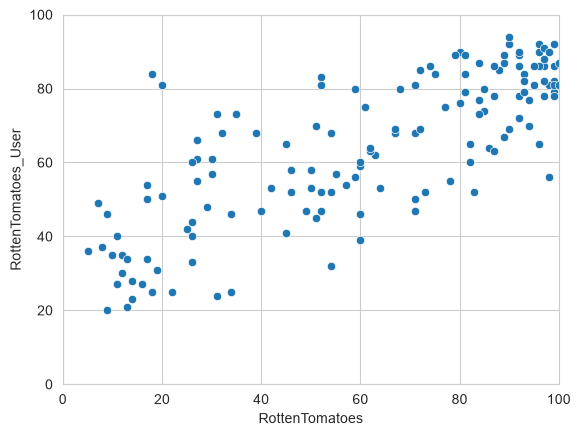

In [32]:
# Críticos vs usuarios de Rotten Tomatoes
sns.scatterplot(data=all_sites, x='RottenTomatoes', y='RottenTomatoes_User')
plt.xlim(0, 100)
plt.ylim(0, 100)

**TAREA 16:** Crea una columna `Rotten_Diff = RottenTomatoes - RottenTomatoes_User`. Valores positivos significan que los **críticos calificaron más alto que los usuarios**; valores negativos, lo opuesto.

In [33]:
# Diferencia entre criticos y usuarios en RT
all_sites['Rotten_Diff'] = all_sites['RottenTomatoes'] - all_sites['RottenTomatoes_User']

**TAREA 17:** Calcula la **diferencia absoluta promedio** entre críticos y usuarios en RT. Esto te dice, en promedio, qué tan distintas son las dos calificaciones (sin que se cancelen entre sí).

In [34]:
# Promedio de la diferencia absoluta entre críticos y usuarios
all_sites['Rotten_Diff'].abs().mean()

np.float64(15.095890410958905)

**TAREA 18:** Visualiza la distribución de `Rotten_Diff` con un `histplot` (con curva KDE encima). Deberías ver valores positivos y negativos.

<Axes: xlabel='Rotten_Diff', ylabel='Count'>

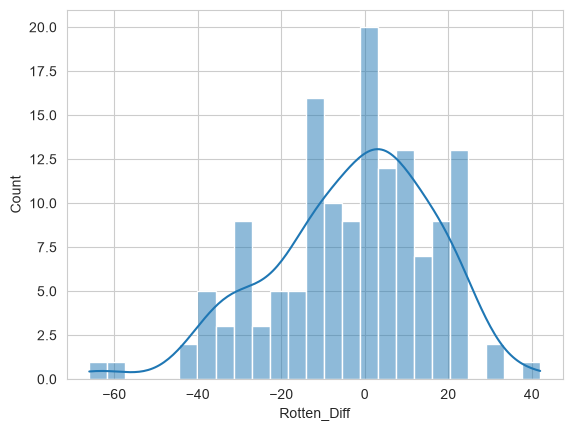

In [35]:
# Distribución de la diferencia (críticos - usuarios)
sns.histplot(data=all_sites, x='Rotten_Diff', kde=True, bins=25)

**TAREA 19:** Ahora visualiza la distribución del **valor absoluto** de la diferencia.

<Axes: xlabel='Rotten_Diff', ylabel='Count'>

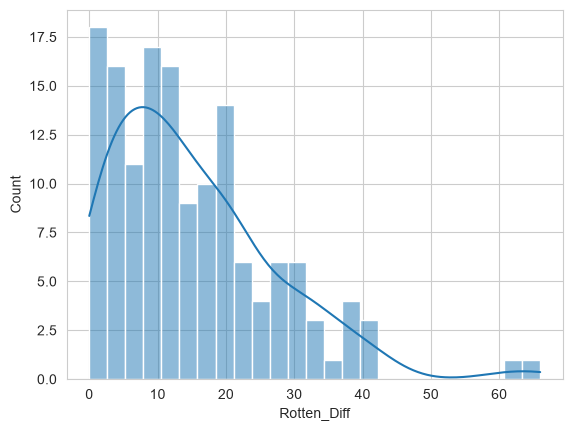

In [36]:
# Distribución de la magnitud de la diferencia
sns.histplot(data=all_sites, x=all_sites['Rotten_Diff'].abs(), kde=True, bins=25)

### Películas más polémicas en Rotten Tomatoes

**TAREA 20:** Muestra las **5 películas con la mayor diferencia negativa** (es decir, donde los **usuarios calificaron mucho más alto que los críticos**). Solo necesitas las columnas `FILM` y `Rotten_Diff`.

In [37]:
# Usuarios calificaron mucho más alto que los críticos (diferencia más negativa)
all_sites.nsmallest(5, 'Rotten_Diff')[['FILM', 'Rotten_Diff']]

,FILM,Rotten_Diff
3,Do You Believe? (2015),-66
85,Little Boy (2015),-61
105,Hitman: Agent 47 (2015),-42
134,The Longest Ride (2015),-42
125,The Wedding Ringer (2015),-39


**TAREA 21:** Ahora las **5 películas con la mayor diferencia positiva** (los críticos las amaron, los usuarios no).

In [38]:
# Críticos calificaron mucho más alto que los usuarios (diferencia más positiva)
all_sites.nlargest(5, 'Rotten_Diff')[['FILM', 'Rotten_Diff']]

,FILM,Rotten_Diff
69,Mr. Turner (2014),42
112,It Follows (2015),31
115,While We're Young (2015),31
37,Welcome to Me (2015),24
40,I'll See You In My Dreams (2015),24


---

### Metacritic

Metacritic, igual que RT, separa críticos profesionales (`Metacritic`, escala 0–100) y usuarios (`Metacritic_User`, escala 0–10).

**TAREA 22:** Construye un scatter de `Metacritic` vs. `Metacritic_User`.

<Axes: xlabel='Metacritic', ylabel='Metacritic_User'>

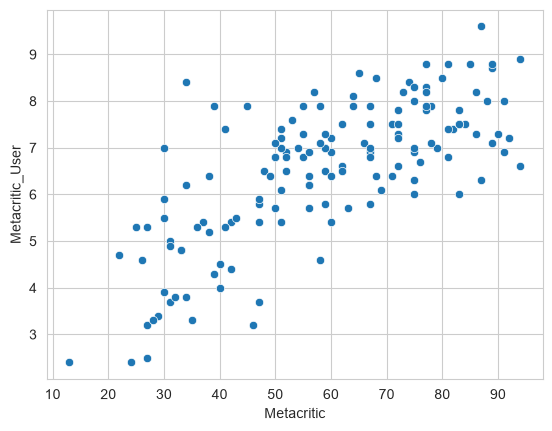

In [39]:
# Críticos vs usuarios de Metacritic
sns.scatterplot(data=all_sites, x='Metacritic', y='Metacritic_User')

---

### IMDb y popularidad

Tanto Metacritic como IMDb reportan número de votos. Comparemos qué tan masiva es la base de votantes en cada sitio.

**TAREA 23:** Scatter de `Metacritic_user_vote_count` vs. `IMDB_user_vote_count`.

<Axes: xlabel='Metacritic_user_vote_count', ylabel='IMDB_user_vote_count'>

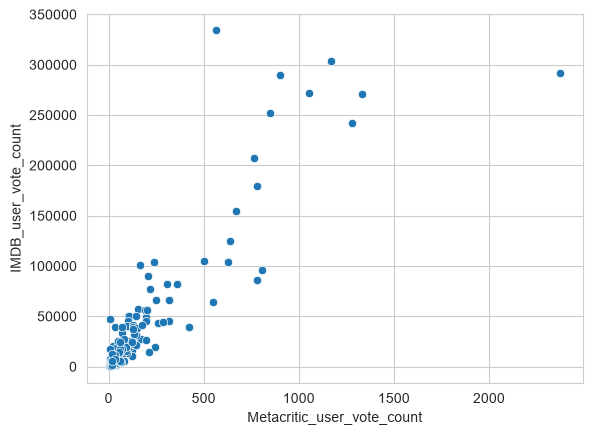

In [40]:
# Comparación de la base de votantes entre Metacritic e IMDb
sns.scatterplot(data=all_sites, x='Metacritic_user_vote_count', y='IMDB_user_vote_count')

**TAREA 24:** ¿Cuál es la película con **más votos en IMDb**?

In [41]:
# Película con más votos de usuarios en IMDb
all_sites.nlargest(1, 'IMDB_user_vote_count')[['FILM', 'IMDB_user_vote_count']]

,FILM,IMDB_user_vote_count
14,The Imitation Game (2014),334164


**TAREA 25:** ¿Y la que tiene **más votos en Metacritic**?

In [42]:
# Película con más votos de usuarios en Metacritic
all_sites.nlargest(1, 'Metacritic_user_vote_count')[['FILM', 'Metacritic_user_vote_count']]

,FILM,Metacritic_user_vote_count
88,Mad Max: Fury Road (2015),2375


---

## Parte 4 — Fandango vs. el resto del mundo

Ahora viene la pregunta que dispara todo el proyecto: **¿muestra Fandango calificaciones sistemáticamente más altas que sitios independientes?**

Para responder necesitamos:

1. **Combinar** las dos tablas por nombre de película (`FILM`).
2. **Normalizar** todas las escalas a 0–5 (la escala de Fandango), para poder comparar.
3. **Comparar distribuciones** lado a lado.

### Combinación de tablas

**TAREA 26:** Haz un `merge` interno entre `fandango` y `all_sites` por la columna `FILM`. Llámalo `df`. Solo nos interesan las películas que aparezcan en **ambas** tablas.

In [43]:
# Combinar ambas tablas; solo películas presentes en las dos
df = pd.merge(fandango, all_sites, on='FILM', how='inner')

### Normalización a escala 0–5

Rotten Tomatoes y Metacritic usan 0–100; IMDb y Metacritic_User usan 0–10; solo Fandango usa 0–5. Para comparar manzanas con manzanas, llevemos todo a 0–5.

**TAREA 27:** Crea las siguientes columnas normalizadas (redondeadas a 1 decimal):

- `RT_Norm`     = `RottenTomatoes / 20`
- `RTU_Norm`    = `RottenTomatoes_User / 20`
- `Meta_Norm`   = `Metacritic / 20`
- `Meta_U_Norm` = `Metacritic_User / 2`
- `IMDB_Norm`   = `IMDB / 2`

> **Cuidado:** no ejecutes esta celda dos veces seguidas, porque seguirías dividiendo. Si te pasa, recarga `df` desde el merge.

In [44]:
# Llevar todas las escalas a 0-5 para poder comparar
df['RT_Norm'] = (df['RottenTomatoes'] / 20).round(1)
df['RTU_Norm'] = (df['RottenTomatoes_User'] / 20).round(1)
df['Meta_Norm'] = (df['Metacritic'] / 20).round(1)
df['Meta_U_Norm'] = (df['Metacritic_User'] / 2).round(1)
df['IMDB_Norm'] = (df['IMDB'] / 2).round(1)

**TAREA 28:** Crea un DataFrame `norm_scores` que solo contenga las columnas comparables: `STARS`, `RATING`, `RT_Norm`, `RTU_Norm`, `Meta_Norm`, `Meta_U_Norm`, `IMDB_Norm`.

In [45]:
# Solo las columnas comparables en escala 0-5
norm_scores = df[['STARS', 'RATING', 'RT_Norm', 'RTU_Norm', 'Meta_Norm', 'Meta_U_Norm', 'IMDB_Norm']]

### El gran panorama

**TAREA 29:** Construye un **KDE plot** que superponga las distribuciones normalizadas de las 7 columnas. Limita a [0, 5].

(0.0, 5.0)

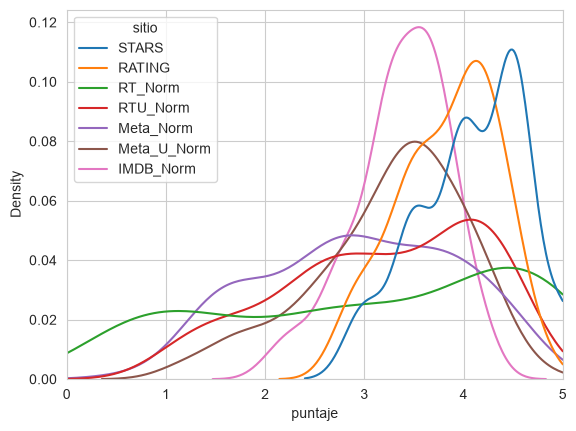

In [46]:
# Densidades de los 7 indicadores normalizados superpuestos
sns.kdeplot(data=norm_scores.melt(var_name='sitio', value_name='puntaje'),
            x='puntaje', hue='sitio', clip=[0, 5])
plt.xlim(0, 5)

**TAREA 30:** Para hacer el contraste más nítido, grafica **solo dos curvas KDE**: `RT_Norm` (críticos profesionales, los más estrictos) vs. `STARS` (Fandango).

(0.0, 5.0)

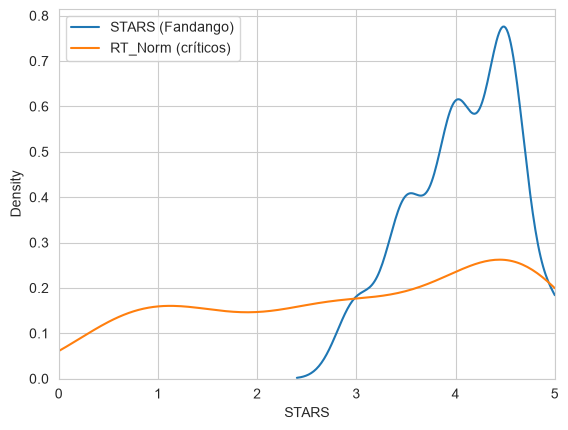

In [47]:
# Fandango vs. los críticos profesionales (los más estrictos)
sns.kdeplot(data=df, x='STARS', label='STARS (Fandango)', clip=[0, 5])
sns.kdeplot(data=df, x='RT_Norm', label='RT_Norm (críticos)', clip=[0, 5])
plt.legend()
plt.xlim(0, 5)

**TAREA 31 (opcional):** Visualiza todas las distribuciones normalizadas con un solo `histplot` (50 bins).

(0.0, 5.0)

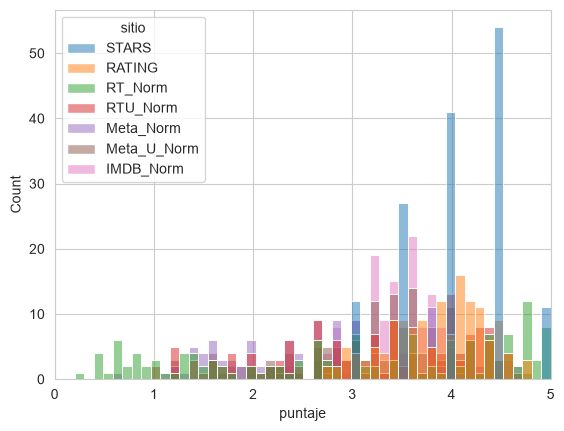

In [48]:
# Histograma de los 7 indicadores normalizados (50 bins)
sns.histplot(data=norm_scores.melt(var_name='sitio', value_name='puntaje'),
             x='puntaje', hue='sitio', bins=50, alpha=0.5)
plt.xlim(0, 5)

### Mapa de calor jerárquico

**TAREA 32:** Construye un `clustermap` con `norm_scores`, paleta `magma`, sin clusterizar columnas (`col_cluster=False`). Esto te permitirá ver patrones por película — qué tan rojas son las películas mejor calificadas y qué tan oscuras las peor calificadas, **a lo largo de los 7 indicadores simultáneamente**.

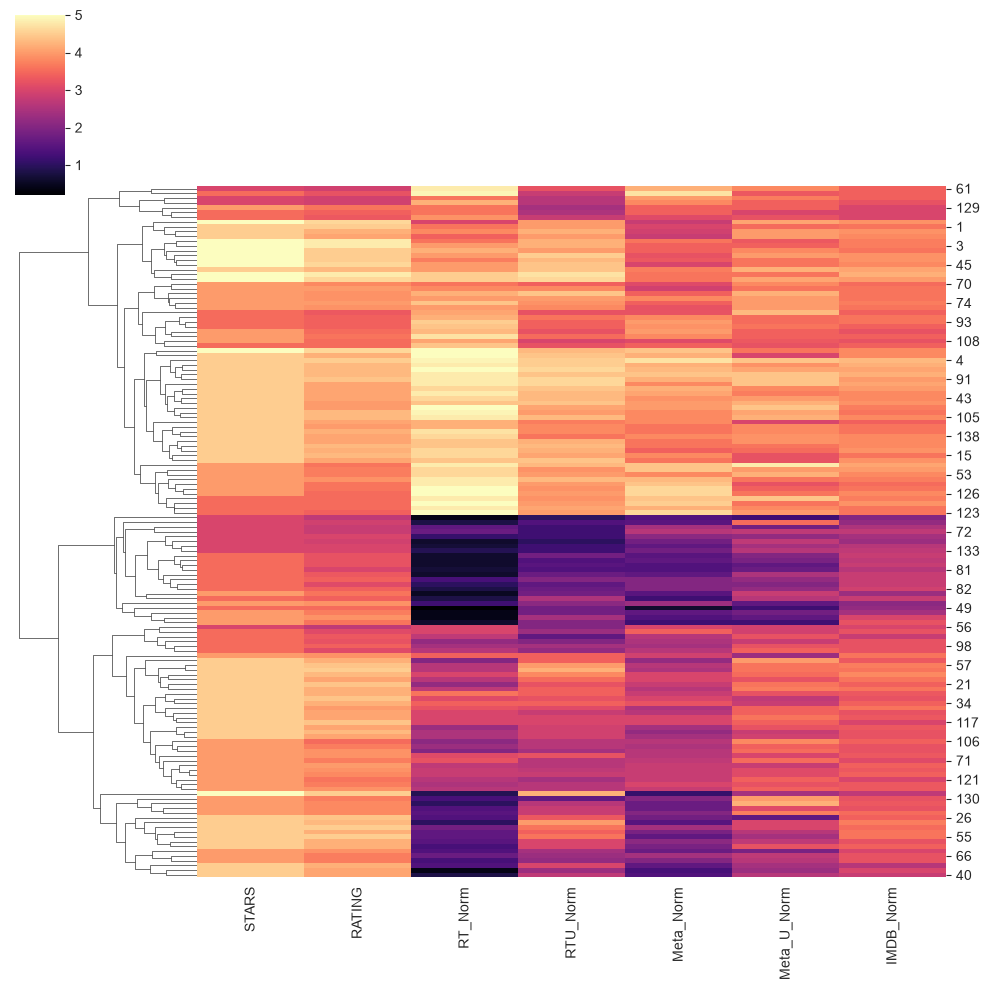

In [49]:
# Mapa de calor jerárquico: patrones por película en los 7 indicadores
sns.clustermap(norm_scores, cmap='magma', col_cluster=False)

### Las 10 películas peor calificadas (según RT)

**TAREA 33:** Toma como referencia la calificación normalizada de los **críticos de Rotten Tomatoes** (`RT_Norm`) y muestra las 10 películas con la calificación más baja. Incluye la columna `FILM` para poder identificarlas.

In [50]:
# Las 10 peores películas según los críticos de Rotten Tomatoes
peores_rt = df.nsmallest(10, 'RT_Norm')[['FILM', 'RT_Norm']]

**TAREA 34 (final):** Para esas 10 peores películas según los críticos, grafica las distribuciones de calificación a través de **todos los sitios** con un KDE.

(0.0, 5.0)

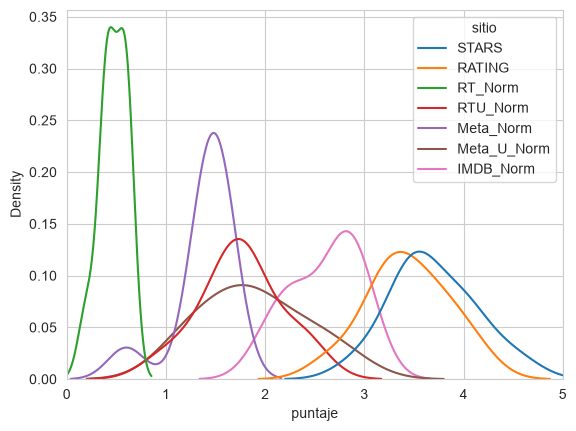

In [51]:
# Distribuciones normalizadas (0-5) de las 10 peores películas en todos los sitios
peores = df[df['FILM'].isin(peores_rt['FILM'])][['STARS', 'RATING', 'RT_Norm', 'RTU_Norm',
                                                 'Meta_Norm', 'Meta_U_Norm', 'IMDB_Norm']]
sns.kdeplot(data=peores.melt(var_name='sitio', value_name='puntaje'),
            x='puntaje', hue='sitio', clip=[0, 5])
plt.xlim(0, 5)

---

## Conclusión

Acabas de reproducir el análisis del artículo de FiveThirtyEight con tus propios datos. Los hallazgos son consistentes con los de Walt Hickey en 2015:

1. **Fandango infla las estrellas mostradas** respecto a su propio cálculo interno. Nunca redondea hacia abajo, solo hacia arriba.
2. **Comparado con sitios independientes** (Rotten Tomatoes, Metacritic, IMDb), Fandango muestra calificaciones **sistemáticamente más altas**.
3. **Hasta para las películas universalmente reconocidas como malas** (críticas en RT por debajo de 1.5/5), Fandango aún mostraba 3.5–4.5 estrellas — incentivando ventas de boletos para películas que la mayoría de fuentes consideraban deficientes.

> **Nota histórica:** después de la publicación del artículo de Hickey, Fandango **modificó silenciosamente su algoritmo de display de estrellas**, dejando de redondear sistemáticamente hacia arriba. Es un buen ejemplo del impacto del **periodismo de datos** sobre las prácticas comerciales reales.

### Reflexiones para el cierre

- ¿Qué otros sitios de e-commerce con calificaciones podrían tener el mismo conflicto de interés?
- ¿Cómo diseñarías un sistema de calificaciones **resistente a este tipo de manipulación**?
- Si fueras analista de datos contratado por Fandango (antes de 2015), ¿qué hubieras recomendado a la gerencia?
